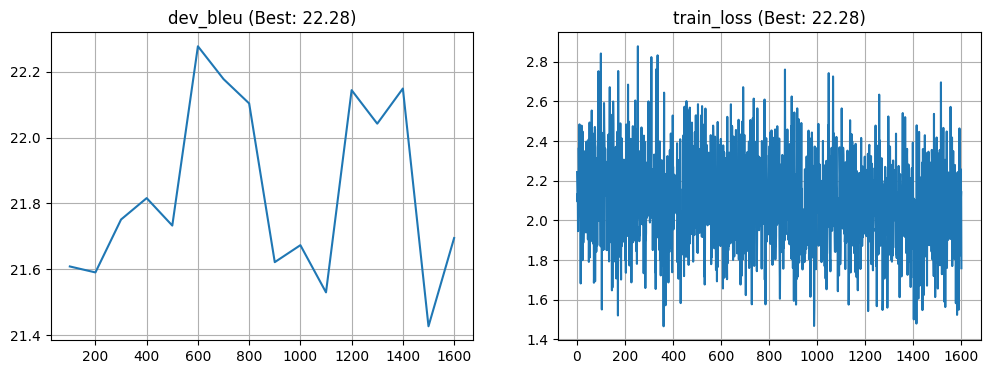

  6%|▋         | 1599/25000 [02:37<38:17, 10.18it/s]

Early Stopping! Best BLEU: 22.28


In [2]:
# =================================================================
# 1. УСТАНОВКА БИБЛИОТЕК И ЗАГРУЗКА ДАННЫХ
# =================================================================
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm import trange
import nltk

# Скачивание необходимых файлов и установка BPE
!pip install subword-nmt
if not os.path.exists('data.txt'):
    !wget https://www.dropbox.com/s/yy2zqh34dyhv07i/data.txt?dl=1 -O data.txt
if not os.path.exists('vocab.py'):
    !wget https://raw.githubusercontent.com/yandexdataschool/nlp_course/2020/week04_seq2seq/vocab.py -O vocab.py

from vocab import Vocab
from nltk.tokenize import WordPunctTokenizer
from subword_nmt.learn_bpe import learn_bpe
from subword_nmt.apply_bpe import BPE

# Настройка устройства (GPU / MPS / CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Используем устройство: {device}")

# =================================================================
# 2. ПРЕДОБРАБОТКА ТЕКСТА И BPE
# =================================================================
tokenizer = WordPunctTokenizer()
def tokenize(x):
    return ' '.join(tokenizer.tokenize(x.lower()))

# Чтение и токенизация
data_inp, data_out = [], []
for line in open('data.txt'):
    src, dst = line.strip().split('\t')
    data_inp.append(tokenize(src))
    data_out.append(tokenize(dst))

# Обучение BPE
with open('train.ru', 'w') as f: f.write('\n'.join(data_inp))
with open('train.en', 'w') as f: f.write('\n'.join(data_out))
learn_bpe(open('train.ru'), open('bpe_rules.ru', 'w'), num_symbols=8000)
learn_bpe(open('train.en'), open('bpe_rules.en', 'w'), num_symbols=8000)

bpe_ru = BPE(open('bpe_rules.ru'))
bpe_en = BPE(open('bpe_rules.en'))

data_inp = np.array([bpe_ru.process_line(l) for l in data_inp])
data_out = np.array([bpe_en.process_line(l) for l in data_out])

# Сплит данных
from sklearn.model_selection import train_test_split
train_inp, dev_inp, train_out, dev_out = train_test_split(data_inp, data_out, test_size=3000, random_state=42)

inp_voc = Vocab.from_lines(train_inp)
out_voc = Vocab.from_lines(train_out)

# =================================================================
# 3. АРХИТЕКТУРА МОДЕЛИ (Basic, Attention, Attentive)
# =================================================================
class BasicModel(nn.Module):
    def __init__(self, inp_voc, out_voc, emb_size=64, hid_size=128):
        super().__init__()
        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size
        self.emb_inp = nn.Embedding(len(inp_voc), emb_size)
        self.emb_out = nn.Embedding(len(out_voc), emb_size)
        self.enc0 = nn.GRU(emb_size, hid_size, batch_first=True)
        self.dec_start = nn.Linear(hid_size, hid_size)
        self.dec0 = nn.GRUCell(emb_size, hid_size)
        self.logits = nn.Linear(hid_size, len(out_voc))

    def forward(self, inp, out):
        initial_state = self.encode(inp)
        return self.decode(initial_state, out)

    def decode(self, initial_state, out_tokens, **flags):
        batch_size = out_tokens.shape[0]
        state = initial_state
        onehot_bos = F.one_hot(torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64),
                               num_classes=len(self.out_voc)).to(device=out_tokens.device)
        first_logits = torch.log(onehot_bos.to(torch.float32) + 1e-9)
        logits_sequence = [first_logits]
        for i in range(out_tokens.shape[1] - 1):
            state, logits = self.decode_step(state, out_tokens[:, i])
            logits_sequence.append(logits)
        return torch.stack(logits_sequence, dim=1)

    def decode_inference(self, initial_state, max_len=100, **flags):
        batch_size, device = len(initial_state[0]), initial_state[0].device
        state = initial_state
        outputs = [torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64, device=device)]
        all_states = [initial_state]
        for i in range(max_len):
            state, logits = self.decode_step(state, outputs[-1])
            outputs.append(logits.argmax(dim=-1))
            all_states.append(state)
        return torch.stack(outputs, dim=1), all_states

    def translate_lines(self, inp_lines, **kwargs):
        inp = self.inp_voc.to_matrix(inp_lines).to(device)
        initial_state = self.encode(inp)
        out_ids, states = self.decode_inference(initial_state, **kwargs)
        return self.out_voc.to_lines(out_ids.cpu().numpy()), states

class AttentionLayer(nn.Module):
    def __init__(self, name, enc_size, dec_size, hid_size, activ=torch.tanh):
        super().__init__()
        self.W_enc = nn.Parameter(torch.randn(enc_size, hid_size) * 0.01)
        self.W_dec = nn.Parameter(torch.randn(dec_size, hid_size) * 0.01)
        self.V = nn.Parameter(torch.randn(hid_size, 1) * 0.01)
        self.activ = activ

    def forward(self, enc, dec, inp_mask):
        enc_part = torch.matmul(enc, self.W_enc)
        dec_part = torch.matmul(dec, self.W_dec).unsqueeze(1)
        logits = torch.matmul(self.activ(enc_part + dec_part), self.V).squeeze(-1)
        logits = torch.where(inp_mask.bool(), logits, torch.ones_like(logits) * -1e9)
        probs = F.softmax(logits, dim=-1)
        attn = (enc * probs.unsqueeze(-1)).sum(dim=1)
        return attn, probs

class AttentiveModel(BasicModel):
    def __init__(self, name, inp_voc, out_voc, emb_size=64, hid_size=128, attn_size=128):
        nn.Module.__init__(self)
        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size
        self.emb_inp = nn.Embedding(len(inp_voc), emb_size)
        self.emb_out = nn.Embedding(len(out_voc), emb_size)
        self.enc0 = nn.GRU(emb_size, hid_size, batch_first=True)
        self.attn = AttentionLayer('attn', hid_size, hid_size, attn_size)
        self.dec0 = nn.GRUCell(emb_size + hid_size, hid_size)
        self.dec_start = nn.Linear(hid_size, hid_size)
        self.logits = nn.Linear(hid_size, len(out_voc))

    def encode(self, inp, **flags):
        inp_emb = self.emb_inp(inp)
        enc_seq, _ = self.enc0(inp_emb)
        lengths = (inp != self.inp_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1)
        last_state = enc_seq[torch.arange(len(enc_seq)), lengths]
        inp_mask = self.inp_voc.compute_mask(inp)
        dec_start = self.dec_start(last_state)
        _, first_attn_probas = self.attn(enc_seq, dec_start, inp_mask)
        return [dec_start, enc_seq, inp_mask, first_attn_probas]

    def decode_step(self, prev_state, prev_tokens, **flags):
        prev_gru_state, enc_seq, inp_mask, _ = prev_state
        attn_res, next_attn_probas = self.attn(enc_seq, prev_gru_state, inp_mask)
        x = self.emb_out(prev_tokens)
        x_and_attn = torch.cat([x, attn_res], dim=-1)
        new_dec_state = self.dec0(x_and_attn, prev_gru_state)
        output_logits = self.logits(new_dec_state)
        return [new_dec_state, enc_seq, inp_mask, next_attn_probas], output_logits

# =================================================================
# 4. УТИЛИТЫ (Loss, BLEU)
# =================================================================
def compute_loss(model, inp, out, **flags):
    mask = model.out_voc.compute_mask(out)
    targets_1hot = F.one_hot(out, len(model.out_voc)).to(torch.float32)
    logits_seq = model(inp, out)
    logprobs_seq = F.log_softmax(logits_seq, dim=-1)
    logp_out = (logprobs_seq * targets_1hot).sum(dim=-1)
    return -torch.sum(logp_out * mask) / torch.sum(mask)

def compute_bleu(model, inp_lines, out_lines, bpe_sep='@@ ', **flags):
    from nltk.translate.bleu_score import corpus_bleu
    with torch.no_grad():
        translations, _ = model.translate_lines(inp_lines, **flags)
        translations = [line.replace(bpe_sep, '') for line in translations]
        actual = [line.replace(bpe_sep, '') for line in out_lines]
        return corpus_bleu([[ref.split()] for ref in actual], [trans.split() for trans in translations],
                           smoothing_function=lambda precisions, **kw: [p + 1.0 / p.denominator for p in precisions]) * 100

# =================================================================
# 5. ЦИКЛ ОБУЧЕНИЯ С СОХРАНЕНИЕМ И ОСТАНОВКОЙ
# =================================================================
MODEL_SAVE_PATH = 'attentive_model_best.pt'
PATIENCE = 10 
metrics = {'train_loss': [], 'dev_bleu': []}
best_bleu = -1
steps_without_improvement = 0

model = AttentiveModel('model_attn', inp_voc, out_voc).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# Авто-загрузка
if os.path.exists(MODEL_SAVE_PATH):
    print("Загружаем сохраненную модель...")
    checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    opt.load_state_dict(checkpoint['optimizer_state_dict'])
    best_bleu = checkpoint.get('best_bleu', -1)
    print(f"Загружено. Текущий лучший BLEU: {best_bleu:.2f}")

plt.ion()
for _ in trange(25000):
    step = len(metrics['train_loss']) + 1
    batch_ix = np.random.randint(len(train_inp), size=32)
    batch_inp = inp_voc.to_matrix(train_inp[batch_ix]).to(device)
    batch_out = out_voc.to_matrix(train_out[batch_ix]).to(device)

    model.train()
    loss_t = compute_loss(model, batch_inp, batch_out)
    opt.zero_grad()
    loss_t.backward()
    opt.step()
    metrics['train_loss'].append((step, loss_t.item()))

    if step % 100 == 0:
        model.eval()
        current_bleu = compute_bleu(model, dev_inp, dev_out)
        metrics['dev_bleu'].append((step, current_bleu))

        if current_bleu > best_bleu:
            best_bleu = current_bleu
            steps_without_improvement = 0
            torch.save({'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': opt.state_dict(),
                        'best_bleu': best_bleu}, MODEL_SAVE_PATH)
        else:
            steps_without_improvement += 1

        clear_output(wait=True)
        fig = plt.figure(figsize=(12, 4))
        for i, (name, history) in enumerate(sorted(metrics.items())):
            plt.subplot(1, len(metrics), i + 1)
            plt.title(f"{name} (Best: {best_bleu:.2f})")
            plt.plot(*zip(*history))
            plt.grid()
        plt.show()
        plt.close(fig)
        
        if steps_without_improvement >= PATIENCE:
            print(f"Early Stopping! Best BLEU: {best_bleu:.2f}")
            break

In [3]:

model.eval()

final_bleu = compute_bleu(model, dev_inp, dev_out)
print(f"Итоговый BLEU на валидации: {final_bleu:.3f}")

Итоговый BLEU на валидации: 21.695


In [4]:
print("Примеры работы модели:")
print("-" * 30)

indices = np.random.choice(len(dev_inp), 5)
for i in indices:
    inp_line = dev_inp[i]
    ref_line = dev_out[i]
    
    trans_line, _ = model.translate_lines([inp_line])
    
    print(f"Оригинал: {inp_line.replace('@@ ', '')}")
    print(f"Эталон:   {ref_line.replace('@@ ', '')}")
    print(f"Модель:   {trans_line[0].replace('@@ ', '')}")
    print("-" * 30)

Примеры работы модели:
------------------------------
Оригинал: located 18 km from gubbio , borgo di carpiano offers an outdoor saltwater pool , restaurant and rooms with air conditioning . wi - fi is free throughout .
Эталон:   в фермерском доме borgo di carpiano , расположенном в 18 км от города губбио , к услугам гостей оборудованные кондиционером номера , открытый бассейн с соленой водой , ресторан и бесплатный wifi .
Модель:   отель типа « постель и завтрак » расположен в 18 км от города агук , в распоряжении гостей номера с бесплатным wi - fi , ресторан и номера с кондиционером и бесплатным wi - fi .
------------------------------
Оригинал: meeting rooms and function halls are available on site .
Эталон:   гости могут пользоваться залом для проведения совещаний и банкетным залом .
Модель:   в числе удобств — телевизор и персональные залы для проведения совещаний .
------------------------------
Оригинал: holiday home stendyssevej henne xii is located in henne .
Эталон:   дом для 